In [1]:
import os, time, shutil, datetime
import numpy as np
import yaml
from astropy.io import fits
import astropy.units as u
import EXOSIMS.MissionSim as ems
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize
from scipy.interpolate import interp1d
from etc_utils import *

from EXOSIMS.util.deltaMag import deltaMag

from synphot import Observation
from synphot import SourceSpectrum
from astropy.modeling.models import Tabular1D

from EXOSIMS.OpticalSystem.MHRS import write_snr_results_to_file, read_snr_results_from_file


import matplotlib.pyplot as plt
import numpy as np
import json
import ternary


Nemati

In [2]:

# R_list = [20,50,140,400,1000,3000,10000]
R = 1000
# override_local_starlight_flux_ratio_list = [1e-10,1e-12]
override_local_starlight_flux_ratio = 1e-10
# ppFact_Char_list = [1,0.1,0.01]
ppFact_Char = 0.1

n_EZ = 3  # nEZ is the number of "zodis" where 1 zodi is equivalent to the amount of dust in the solar system. So it's like a way to tune the amount of dust in a planetary system
# pl_dist_ee_coefs =  [0.95,1.0,1.35,1.67]
pl_dist_ee_coef =  1.0
p = 0.2 # Max albedo of the planet
Rp = 1 * u.earthRad # Planet Radius
n_angles = 1#len(pl_dist_ee_coefs)

scriptfile = "/home/jruffio/code/EXOSIMS_MHRS_scripts/configs/20250621_exosims_genOutSpec_Nemati_Romandetecnoise.json"
with open(scriptfile, "r") as ff:
    script = ff.read()
exosims_pars_dict = json.loads(script)

assert 'imager' in exosims_pars_dict['observingModes'][0]['instName'], "1st instrument in observingModes list is not a imager"
assert 'spectro' in exosims_pars_dict['observingModes'][1]['instName'], "2nd instrument in observingModes list is not a spectrograph"
assert 'imager' in exosims_pars_dict['scienceInstruments'][0]['name'], "1st instrument in scienceInstruments list is not a imager"
assert 'spectro' in exosims_pars_dict['scienceInstruments'][1]['name'], "2nd instrument in scienceInstruments list is not a spectrograph"

target_list = ["HIP 79672"]
if target_list is not None:
    exosims_pars_dict['cherryPickStars'] = target_list
    print(exosims_pars_dict['cherryPickStars'])
exosims_pars_dict['scienceInstruments'][1]["Rs"] = R
exosims_pars_dict['starlightSuppressionSystems'][0]["override_local_starlight_flux_ratio"] = override_local_starlight_flux_ratio
exosims_pars_dict["ppFact_char"] = ppFact_Char


sim = ems.MissionSim(**deepcopy(exosims_pars_dict))
# sim = ems.MissionSim(scriptfile,use_core_thruput_for_ez=False)
# sim.genOutSpec("/fast/jruffio/data/exosims/exosims_samples/20250528_exosims_genOutSpec_MHRS.json")

sInds = np.array([np.where(sim.TargetList.Name == t)[0][0] for t in sim.TargetList.Name])
eeid_au_TL = sim.TargetList.calc_EEID(sInds).to(u.au).value # in AU
eeid_as_TL = eeid_au_TL / sim.TargetList.dist[sInds].to(u.pc).value # in as
WA_au_TL = pl_dist_ee_coef * eeid_au_TL
WA_as_TL = pl_dist_ee_coef * eeid_as_TL
d_TL = WA_au_TL * u.au # Planet-star distance in units of AU
# Planet phase function
beta = np.pi/2 *u.rad
phi = sim.SimulatedUniverse.PlanetPhysicalModel.calc_Phi(beta)
dMags = np.array([deltaMag(p, Rp, d, phi) for d in d_TL])
# print("dMags",dMags,10**(-dMags/2.5))

fZ = sim.ZodiacalLight.fZ0

mode = sim.OpticalSystem.observingModes[0] # imager: index 0
_JEZ0_TL = sim.TargetList.JEZ0[mode['hex']][sInds]
JEZ_TL = _JEZ0_TL * n_EZ / eeid_au_TL ** 2

# Cp_Cb_Csp(self, TL, sInds, fZ, JEZ, dMag, WA, mode, returnExtra=False, TK=None):
out = sim.OpticalSystem.Cp_Cb_Csp(sim.TargetList,sInds,[fZ.value] * len(sInds) * fZ.unit,
    JEZ_TL,dMags,WA_as_TL * u.arcsec,mode,returnExtra=True)
_C_p , _C_b , _C_sp , C_extra = out
print("_C_p , _C_b , _C_sp",_C_p , _C_b , _C_sp)
for key,val in zip(C_extra.keys(),C_extra.values()):
    print(key, val)

['HIP 79672']
Imported SurveySimulation (prototype) from EXOSIMS.Prototypes.SurveySimulation
Numpy random seed is: 408612100
Imported SimulatedUniverse (prototype) from EXOSIMS.Prototypes.SimulatedUniverse
Imported TargetList (prototype) from EXOSIMS.Prototypes.TargetList


/home/jruffio/code/EXOSIMS/EXOSIMS/Prototypes/TargetList.py:381: UserWarning: binary_filter is None but filterBinaries is False. Using binary_filter value of None.
  warnings.warn(
/home/jruffio/code/EXOSIMS/EXOSIMS/Prototypes/OpticalSystem.py:624: UserWarning: Input focal length (89.38 m) does not match value from pixelScale (178.76 m) for instrument CONF_NF_imager. This feels like a mistkae.
  warnings.warn(
/home/jruffio/code/EXOSIMS/EXOSIMS/Prototypes/OpticalSystem.py:624: UserWarning: Input focal length (89.38 m) does not match value from pixelScale (178.76 m) for instrument CONF_NF_spectro. This feels like a mistkae.
  warnings.warn(
/home/jruffio/code/EXOSIMS/EXOSIMS/Prototypes/OpticalSystem.py:1178: UserWarning: platescale for core_mean_intensity in system coronagraph does not match input value.  Overwriting with value from FITS file but you should check your inputs.
  warnings.warn(
/home/jruffio/code/EXOSIMS/EXOSIMS/MissionSim.py:240: UserWarning: 
The following input keyword

Imported HWOMissionStars (implementation) from EXOSIMS.StarCatalog.HWOMissionStars
Loaded data from /home/jruffio/.EXOSIMS/downloads/HWOStarList_20250408155836.pkl
Imported Nemati (implementation) from EXOSIMS.OpticalSystem.Nemati
Imported ZodiacalLight (prototype) from EXOSIMS.Prototypes.ZodiacalLight
Imported PostProcessing (prototype) from EXOSIMS.Prototypes.PostProcessing
Imported BackgroundSources (prototype) from EXOSIMS.Prototypes.BackgroundSources
Imported Completeness (prototype) from EXOSIMS.Prototypes.Completeness
Imported PlanetPopulation (prototype) from EXOSIMS.Prototypes.PlanetPopulation
Imported PlanetPhysicalModel (prototype) from EXOSIMS.Prototypes.PlanetPhysicalModel
Loaded JEZ0 values from /home/jruffio/.EXOSIMS/cache/TargetList_HWOMissionStarsnStars_1_mode_c2d65e00e2d21c5f1545584f6323a758.JEZ0
Loaded JEZ0 values from /home/jruffio/.EXOSIMS/cache/TargetList_HWOMissionStarsnStars_1_mode_b89cec5a280e201a3ce175e34db42403.JEZ0
Loaded star fluxes values from /home/jruffi

In [3]:
# R_list = [20,50,140,400,1000,3000,10000]
R = 1000
# override_local_starlight_flux_ratio_list = [1e-10,1e-12]
override_local_starlight_flux_ratio = 1e-10
# ppFact_Char_list = [1,0.1,0.01]
ppFact_Char = 0.1

n_EZ = 3  # nEZ is the number of "zodis" where 1 zodi is equivalent to the amount of dust in the solar system. So it's like a way to tune the amount of dust in a planetary system
# pl_dist_ee_coefs =  [0.95,1.0,1.35,1.67]
pl_dist_ee_coef =  1.0
p = 0.2 # Max albedo of the planet
Rp = 1 * u.earthRad # Planet Radius
n_angles = 1#len(pl_dist_ee_coefs)
# target_list = None
# target_list = ["HIP 32439 A","HIP 77052 A","HIP 79672","HIP 26779","HIP 113283"]
target_list = ["HIP 79672"]

scriptfile = "/fast/jruffio/data/exosims/exosims_samples/20250528_exosims_genOutSpec_MHRS_Romandetecnoise.json"

with open(scriptfile, "r") as ff:
    script = ff.read()
exosims_pars_dict = json.loads(script)
# print(exosims_pars_dict)

# Check that the instruments and observing modes check expectations:
assert 'imager' in exosims_pars_dict['observingModes'][0]['instName'], "1st instrument in observingModes list is not a imager"
assert 'spectro' in exosims_pars_dict['observingModes'][1]['instName'], "2nd instrument in observingModes list is not a spectrograph"
assert 'imager' in exosims_pars_dict['scienceInstruments'][0]['name'], "1st instrument in scienceInstruments list is not a imager"
assert 'spectro' in exosims_pars_dict['scienceInstruments'][1]['name'], "2nd instrument in scienceInstruments list is not a spectrograph"

if target_list is not None:
    exosims_pars_dict['cherryPickStars'] = target_list
    # print(exosims_pars_dict['cherryPickStars'])

exosims_pars_dict['scienceInstruments'][1]["Rs"] = R
exosims_pars_dict['starlightSuppressionSystems'][0]["override_local_starlight_flux_ratio"] = override_local_starlight_flux_ratio
exosims_pars_dict["ppFact_char"] = ppFact_Char
print("Spectral resolution R: ",exosims_pars_dict['scienceInstruments'][1]["Rs"])
print("coronagraph flux ratio: ",exosims_pars_dict['starlightSuppressionSystems'][0]["override_local_starlight_flux_ratio"])
print("Post proc charac factor: ",exosims_pars_dict["ppFact_char"])

sim = ems.MissionSim(**deepcopy(exosims_pars_dict))
# sim = ems.MissionSim(scriptfile,use_core_thruput_for_ez=False)
# sim.genOutSpec("/fast/jruffio/data/exosims/exosims_samples/20250528_exosims_genOutSpec_MHRS.json")

sInds = np.array([np.where(sim.TargetList.Name == t)[0][0] for t in sim.TargetList.Name])
eeid_au_TL = sim.TargetList.calc_EEID(sInds).to(u.au).value # in AU
eeid_as_TL = eeid_au_TL / sim.TargetList.dist[sInds].to(u.pc).value # in as
WA_au_TL = pl_dist_ee_coef * eeid_au_TL
WA_as_TL = pl_dist_ee_coef * eeid_as_TL
d_TL = WA_au_TL * u.au # Planet-star distance in units of AU
# Planet phase function
beta = np.pi/2 *u.rad
phi = sim.SimulatedUniverse.PlanetPhysicalModel.calc_Phi(beta)
dMags = np.array([deltaMag(p, Rp, d, phi) for d in d_TL])
# print("dMags",dMags,10**(-dMags/2.5))

fZ = sim.ZodiacalLight.fZ0

## Load the albedo spectral model
R_pl_template = 400000
# filename1_broad = '/fast/jruffio/data/exosims/model_Renyu/HighResSpec/EarthSpec/GeometricA_Earth_HighCloud_UltraRes_500-1500nm_R{0:.0f}.dat'.format(
#     R_pl_template)
# filename2_broad = '/fast/jruffio/data/exosims/model_Renyu/HighResSpec/EarthSpec/GeometricA_Earth_NoCloud_UltraRes_500-1500nm_R{0:.0f}.dat'.format(
#     R_pl_template)
# filename_broad = '/fast/jruffio/data/exosims/model_Renyu/HighResSpec/EarthSpec/GeometricA_Earth_NoCloud_UltraRes_500-1500nm_R{0:.0f}.dat'.format(R_pl_template)
filename_broad = '/fast/jruffio/data/exosims/model_Renyu/HighResSpec/EarthSpec/GeometricA_Earth_HighCloud_UltraRes.dat'
# data_broad = np.loadtxt(filename1_broad, dtype=float)
# data_broad2 = np.loadtxt(filename2_broad, dtype=float)
data_broad = np.loadtxt(filename_broad, dtype=float)
where_wvs = np.where((data_broad[:,0]>200)*(data_broad[:,0]<1500))
data_broad = data_broad[where_wvs[0],:]
# index 0: Wavelength
# index 1: All
# index 2: H2O
# index 3: CO2
# index 4: N2O
# index 5: CH4
# index 6: O2
# index 7: O3
pl_waves = data_broad[:, 0] * u.nm  # or u.AA, u.nm, etc.
data_broad /= np.nanmean(data_broad[:, 4])
pl_all_template = data_broad[:, 1]  # unitless reflectance
pl_H2O_template = data_broad[:, 2] - data_broad[:, 4]  # unitless reflectance
pl_O2_template = data_broad[:, 6] - data_broad[:, 4]  # unitless reflectance
pl_template = [pl_all_template, pl_H2O_template, pl_O2_template]
pl_template_name = ["all", "H2O", "O2"]
# pl_template_name = ["all","H2O","CO2","N2O","CH4","O2","O3"]
# plt.plot(pl_waves,pl_all_template)
# plt.plot(pl_waves,pl_H2O_template)
# plt.plot(pl_waves,pl_O2_template)
# plt.show()

mode = sim.OpticalSystem.observingModes[1]
_JEZ0_TL = sim.TargetList.JEZ0[mode['hex']][sInds]
JEZ_TL = _JEZ0_TL * n_EZ / eeid_au_TL ** 2

# TL, sInds, fZ, JEZ, dMag, WA, mode, returnExtra=False, TK=None, pl_waves = None,
#        pl_template = None, R_pl_template=None,pl_template_name=None,n_jobs=-1,broaden_pixel=True)
out = sim.OpticalSystem.Cp_Cb_Csp_spec(sim.TargetList,sInds,[fZ.value] * len(sInds) * fZ.unit,
    JEZ_TL,dMags,WA_as_TL * u.arcsec,mode,returnExtra=True,
    R_pl_template=R_pl_template, pl_waves=pl_waves, pl_template=pl_template,pl_template_name=pl_template_name,
    n_jobs=0, broaden_pixel=False)
data_waves = out[0] # Wavelength sampling of the "data", ie the spectra below
pl0_template_scaled_C_p_list = out[1]   # List of planet spectra (including PCeff * NCTE)
_C_b_spec_list = out[2]  # List of white noise stddev spectra (including k_SZ, ENF2, k_det)
star_template_scaled_C_sp_list = out[3] # List of residual starlight spectra, ie correlated noise (_C_sr * post processing factor * stability factor)

print("_C_p , _C_b , _C_sp",np.sum(pl0_template_scaled_C_p_list[0]) , np.sum(_C_b_spec_list[0]) , np.sum(star_template_scaled_C_sp_list[0]))
C_extra = out[4] # The outputs in there do not typically include the photon counting detector stuff
for key,val in zip(C_extra.keys(),C_extra.values()):
    try:
        print(key, np.sum(val[0]))
    except:
        print(key, val)
# pl0_template_scaled_C_p0_list = C_extra["C_p0_spec"] # List of planet spectra (NOT including PCeff * NCTE)
# star_template_scaled_C_sr_list = C_extra["C_sr_spec"] # List of starlight spectra (before post-processing)
# _C_z_spec_list = C_extra["C_z_spec"] # List of Zodi spectra
# _C_ez_spec_list = C_extra["C_ez_spec"] # List of exzodi spectra
# _C_dc_spec_list = C_extra["C_dc_spec"] # List of dark current spectra
# _C_bl_spec_list = C_extra["C_bl_spec"]
# _C_star_spec_list = C_extra["C_star_spec"]
# _C_rn_spec_list = C_extra["C_rn_spec"] # List of read noise spectra
# _C_cc_spec_list = C_extra["C_cc_spec"] # List of clock-induced charge spectra
# Npix = C_extra["Npix_per_bin"]
# k_SZ = C_extra["k_SZ"]
# k_det = C_extra["k_det"]
# ENF2 = C_extra["ENF2"]
# lambda_center = C_extra["lambda_center"] # Center wavelength of the bandpass

Spectral resolution R:  1000
coronagraph flux ratio:  1e-10
Post proc charac factor:  0.1
Imported SurveySimulation (prototype) from EXOSIMS.Prototypes.SurveySimulation
Numpy random seed is: 408612100
Imported SimulatedUniverse (prototype) from EXOSIMS.Prototypes.SimulatedUniverse
Imported TargetList (prototype) from EXOSIMS.Prototypes.TargetList
Imported HWOMissionStars (implementation) from EXOSIMS.StarCatalog.HWOMissionStars
Loaded data from /home/jruffio/.EXOSIMS/downloads/HWOStarList_20250408155836.pkl
Imported MHRS (implementation) from EXOSIMS.OpticalSystem.MHRS
Imported ZodiacalLight (prototype) from EXOSIMS.Prototypes.ZodiacalLight
Imported PostProcessing (prototype) from EXOSIMS.Prototypes.PostProcessing
Imported BackgroundSources (prototype) from EXOSIMS.Prototypes.BackgroundSources
Imported Completeness (prototype) from EXOSIMS.Prototypes.Completeness
Imported PlanetPopulation (prototype) from EXOSIMS.Prototypes.PlanetPopulation
Imported PlanetPhysicalModel (prototype) from

/home/jruffio/code/EXOSIMS/EXOSIMS/Prototypes/TargetList.py:381: UserWarning: binary_filter is None but filterBinaries is False. Using binary_filter value of None.
  warnings.warn(
/home/jruffio/code/EXOSIMS/EXOSIMS/Prototypes/OpticalSystem.py:624: UserWarning: Input focal length (89.38 m) does not match value from pixelScale (178.76 m) for instrument CONF_NF_imager. This feels like a mistkae.
  warnings.warn(
/home/jruffio/code/EXOSIMS/EXOSIMS/Prototypes/OpticalSystem.py:624: UserWarning: Input focal length (89.38 m) does not match value from pixelScale (178.76 m) for instrument CONF_NF_spectro. This feels like a mistkae.
  warnings.warn(
/home/jruffio/code/EXOSIMS/EXOSIMS/Prototypes/OpticalSystem.py:1178: UserWarning: platescale for core_mean_intensity in system coronagraph does not match input value.  Overwriting with value from FITS file but you should check your inputs.
  warnings.warn(
/home/jruffio/code/EXOSIMS/EXOSIMS/MissionSim.py:240: UserWarning: 
The following input keyword

True coucou
True this works
_C_p , _C_b , _C_sp 0.03706015120521484 1 / s 1.1980264646762835 1 / s 0.028013570575581067 1 / s
C_sr_spec 0.2801357057558107 1 / s
C_z_spec 0.06793463952874661 1 / s
C_ez_spec 0.36749786950317076 1 / s
C_dc_spec 0.04657260124544691 1 / s
C_cc_spec 0.3985028998522988 1 / s
C_rn_spec 0.0003225975855947181 1 / s
C_star_spec 1400678528.7790532 1 / s
C_p0_spec 0.03706015120521484 1 / s
C_bl_spec 0.0 1 / s
C_p_mol_spec {'H2O': <Quantity [-2.66209461e-10, -2.75225105e-10, -3.59122779e-10,
           -6.84901022e-10, -4.92423274e-10, -1.69526352e-09,
           -1.68963625e-09, -3.52177595e-09, -4.11322530e-09,
           -6.21230357e-09, -1.03322404e-08, -8.46047272e-09,
           -1.20170729e-08, -1.35959047e-08, -1.29463977e-08,
           -1.47551297e-08, -2.28137244e-08, -1.25388722e-08,
           -7.70743280e-09, -1.43294748e-08, -1.98305787e-08,
           -3.40903475e-08, -6.01586023e-08, -1.63753272e-07,
           -3.77714382e-07, -4.95873325e-07, -6.9

/home/jruffio/code/EXOSIMS/EXOSIMS/OpticalSystem/MHRS.py:426: UserWarning: Instrument resolution is higher than 1/2 the stellar template resolution.
  warnings.warn("Instrument resolution is higher than 1/2 the stellar template resolution.")


In [4]:

print("_C_p , _C_b , _C_sp",np.sum(pl0_template_scaled_C_p_list[0]) , np.sum(_C_b_spec_list[0]) , np.sum(star_template_scaled_C_sp_list[0]))
C_extra = out[4] # The outputs in there do not typically include the photon counting detector stuff
for key,val in zip(C_extra.keys(),C_extra.values()):
    if "C_p_mol_spec" in key:
        continue
    try:
        print(key, np.sum(val[0]))
    except:
        print(key, val)

_C_p , _C_b , _C_sp 0.03706015120521484 1 / s 1.1980264646762835 1 / s 0.028013570575581067 1 / s
C_sr_spec 0.2801357057558107 1 / s
C_z_spec 0.06793463952874661 1 / s
C_ez_spec 0.36749786950317076 1 / s
C_dc_spec 0.04657260124544691 1 / s
C_cc_spec 0.3985028998522988 1 / s
C_rn_spec 0.0003225975855947181 1 / s
C_star_spec 1400678528.7790532 1 / s
C_p0_spec 0.03706015120521484 1 / s
C_bl_spec 0.0 1 / s
Npix_per_bin 3.881050103787241
k_SZ 1.0
k_det 1.0
ENF2 1.0
lambda_center 7499.5 Angstrom


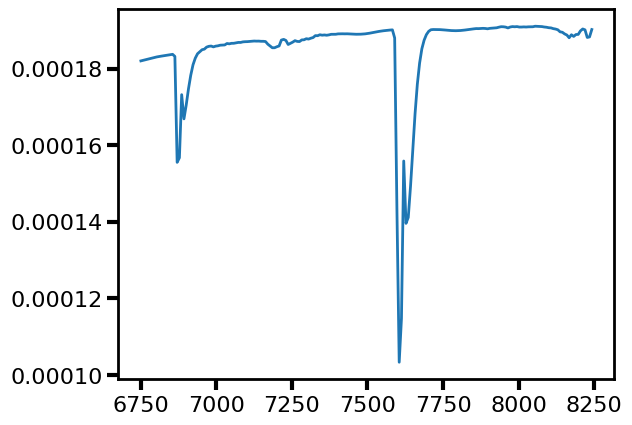

In [3]:
plt.plot(data_waves,pl0_template_scaled_C_p_list[0])